# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** M Kurniadi Pratama P
- **Email:** pratamakurniadi@gmail.com
- **ID Dicoding:** kurniadi_pratama

## Menentukan Pertanyaan Bisnis

- **Pertanyaan 1:** Berapakah rata-rata skor ulasan (review score) yang diberikan pelanggan setiap bulannya sepanjang tahun 2018 untuk melihat apakah kepuasan pelanggan stabil?
- **Pertanyaan 2:** Kategori produk apa yang menghasilkan total pendapatan (revenue) tertinggi bagi perusahaan sepanjang tahun 2018?

## Import Semua Packages/Library yang Digunakan

In [50]:
# 1. Library Utama untuk Manipulasi & Analisis Data
import pandas as pd
import numpy as np

# 2. Library untuk Visualisasi Data
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [51]:
# --- 1. GATHERING DATA ---

# Membaca dataset untuk Pertanyaan 1 (Tren Kepuasan Pelanggan)
try:
    df_reviews = pd.read_csv('order_reviews_dataset.csv')
    print("✓ Data order_reviews berhasil dimuat.")
except FileNotFoundError:
    print("❌ File 'order_reviews_dataset.csv' tidak ditemukan. Pastikan sudah diunggah ke Colab.")

# Membaca dataset untuk Pertanyaan 2 (Kategori Produk Terlaris)
try:
    df_items = pd.read_csv('order_items_dataset.csv')
    df_products = pd.read_csv('products_dataset.csv')
    print("✓ Data order_items dan products berhasil dimuat.")
except FileNotFoundError:
    print("❌ Pastikan file 'order_items_dataset.csv' dan 'products_dataset.csv' sudah diunggah.")

# --- MENGINTIP DATA (PREVIEW) ---
print("\n=== Uji Coba Tampilan Data Reviews ===")
display(df_reviews.head())

print("\n=== Uji Coba Tampilan Data Items ===")
display(df_items.head())

print("\n=== Uji Coba Tampilan Data Products ===")
display(df_products.head())

✓ Data order_reviews berhasil dimuat.
✓ Data order_items dan products berhasil dimuat.

=== Uji Coba Tampilan Data Reviews ===


,",5,Ok,Dentro do prazo. Ok,2018-08-15 00:00:00,2018-08-16 05:28:44\r\n32618eb7390d540e8f851060e051cfe2""",32e4636ad9646a3b7df0dbde0cfe5500,5,Unnamed: 3,Unnamed: 4,2018-01-17 00:00:00,2018-01-18 00:27:20
0,0597885c5017e7a01d792f8eb3026bea,5a6a63148f6ab52879bb7c2d7117e366,5,NaN,NaN,2017-04-12 00:00:00,2017-04-13 01:52:58
1,e6f0b999d1c31296caaf26bc05052144,ab23407c84b934f452124bc5b5453123,5,NaN,NaN,2017-12-20 00:00:00,2017-12-22 20:25:06
2,1d685288da2ae270a895e13beff3edba,a0726e4fe3c5c989d0f89d5432c905b1,2,NaN,NaN,2017-03-02 00:00:00,2017-03-02 19:26:41
3,d9c159bef106ee1f019a494813a24ce9,ce36799829f380bb23aa467649d173c5,1,NaN,NaN,2018-06-08 00:00:00,2018-06-10 23:54:39
4,2a3ddf0bea2f67d4100758ddc238ca8d,676232c436e714d6dcfeae445f02fedd,3,NaN,FONTE DE QUALIDADE.,2018-01-31 00:00:00,2018-01-31 21:00:23



=== Uji Coba Tampilan Data Items ===


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14



=== Uji Coba Tampilan Data Products ===


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


**Insight:** (Opsional)
- file order_reviews_dataset.csv mengalami masalah pemisahan karakter atau pembacaan baris baru (parsing error).
- file order_reviews_dataset.csv tidak memiliki header

### Assessing Data

#### Identifying ... problem

In [52]:
import csv
# Membaca data reviews dengan penanganan khusus teks berantakan
try:
    df_reviews = pd.read_csv(
        'order_reviews_dataset.csv',
        # Jika file asli memang tidak memiliki header, kita definisikan sendiri headernya secara manual
        names=['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp'],
        # Parameter pengaman agar baris baru di dalam teks ulasan tidak dianggap sebagai baris data baru
        escapechar='\\',
        quoting=csv.QUOTE_MINIMAL,
        on_bad_lines='skip' # Lewati baris yang benar-benar rusak parah agar tidak eror
    )
    print("✓ Data order_reviews berhasil dimuat dengan aman!")
except Exception as e:
    print(f"❌ Terjadi kesalahan: {e}")

# Tampilkan 5 baris pertama untuk mengecek hasilnya
display(df_reviews.head())
df_reviews.info()
print("Jumlah duplikasi: ", df_reviews.duplicated().sum())
df_reviews.describe()

✓ Data order_reviews berhasil dimuat dengan aman!


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,",5,Ok,Dentro do prazo. Ok,2018-08-15 00:00:00,...",32e4636ad9646a3b7df0dbde0cfe5500,5,NaN,NaN,2018-01-17 00:00:00,2018-01-18 00:27:20
1,0597885c5017e7a01d792f8eb3026bea,5a6a63148f6ab52879bb7c2d7117e366,5,NaN,NaN,2017-04-12 00:00:00,2017-04-13 01:52:58
2,e6f0b999d1c31296caaf26bc05052144,ab23407c84b934f452124bc5b5453123,5,NaN,NaN,2017-12-20 00:00:00,2017-12-22 20:25:06
3,1d685288da2ae270a895e13beff3edba,a0726e4fe3c5c989d0f89d5432c905b1,2,NaN,NaN,2017-03-02 00:00:00,2017-03-02 19:26:41
4,d9c159bef106ee1f019a494813a24ce9,ce36799829f380bb23aa467649d173c5,1,NaN,NaN,2018-06-08 00:00:00,2018-06-10 23:54:39


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34469 entries, 0 to 34468
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                34469 non-null  object
 1   order_id                 34469 non-null  object
 2   review_score             34469 non-null  int64 
 3   review_comment_title     3898 non-null   object
 4   review_comment_message   14235 non-null  object
 5   review_creation_date     34469 non-null  object
 6   review_answer_timestamp  34469 non-null  object
dtypes: int64(1), object(6)
memory usage: 1.8+ MB
Jumlah duplikasi:  0


,review_score
count,34469.000000
mean,4.084685
std,1.350557
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


In [53]:
df_items.info()
print("Jumlah duplikasi: ", df_items.duplicated().sum())
df_items.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB
Jumlah duplikasi:  0


,order_item_id,price,freight_value
count,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320
std,0.705124,183.633928,15.806405
min,1.000000,0.850000,0.000000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.990000,16.260000
75%,1.000000,134.900000,21.150000
max,21.000000,6735.000000,409.680000


In [54]:
df_products.info()
print("Jumlah duplikasi: ", df_products.duplicated().sum())
df_products.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB
Jumlah duplikasi:  0


,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
mean,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000
max,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000


**Steps to Take:**
- membuat header pada order_reviews_dataset
- mengatasi masalah pemisah kolom dan baris baru yang rusak pada ulasan pelanggan

**Insight:** (Opsional)
- order_reviews bagian review_creation_date & review_answer_timestamp bertipe object
- shipping_limit_date pada order_items juga bertipe data object

### Cleaning Data

#### Fixing kolom tanggal dari teks (object) menjadi tipe datetime

In [55]:
# --- CLEANING DATA (Pertanyaan 1) ---

# A. Mengubah kolom tanggal dari teks (object) menjadi tipe datetime
df_reviews['review_creation_date'] = pd.to_datetime(df_reviews['review_creation_date'])

# B. Mengekstrak tahun dan bulan untuk mempermudah pengelompokkan nanti
df_reviews['year'] = df_reviews['review_creation_date'].dt.year
df_reviews['month'] = df_reviews['review_creation_date'].dt.to_period('M')

# C. Memfilter data agar HANYA mengambil transaksi di tahun 2018
df_reviews_2018 = df_reviews[df_reviews['year'] == 2018].copy()

# D. Memastikan kolom review_score bertipe numerik (integer/float) agar bisa dihitung rata-ratanya
df_reviews_2018['review_score'] = pd.to_numeric(df_reviews_2018['review_score'], errors='coerce')

# E. Menghapus baris yang review_score-nya mendadak kosong/eror saat konversi (jika ada)
df_reviews_2018 = df_reviews_2018.dropna(subset=['review_score'])

print(f"✓ Pembersihan selesai. Jumlah data ulasan di tahun 2018: {df_reviews_2018.shape[0]} baris.")
display(df_reviews_2018[['review_creation_date', 'month', 'review_score']].head())

✓ Pembersihan selesai. Jumlah data ulasan di tahun 2018: 19408 baris.


,review_creation_date,month,review_score
0,2018-01-17,2018-01,5
4,2018-06-08,2018-06,1
5,2018-01-31,2018-01,3
6,2018-04-11,2018-04,5
8,2018-01-05,2018-01,4


In [56]:
# --- 3. CLEANING DATA (Pertanyaan 2: Kategori Terlaris 2018) ---

# A. Membersihkan tabel 'items'
# Mengubah kolom tanggal pengiriman menjadi datetime
df_items['shipping_limit_date'] = pd.to_datetime(df_items['shipping_limit_date'])

# Mengekstrak tahun dan mengambil data HANYA tahun 2018
df_items['year'] = df_items['shipping_limit_date'].dt.year
df_items_2018 = df_items[df_items['year'] == 2018].copy()


# B. Membersihkan tabel 'products'
# Mengisi nilai kosong (NaN) di product_category_name dengan 'unknown'
df_products['product_category_name'] = df_products['product_category_name'].fillna('unknown')


# C. Menggabungkan (Merge) kedua tabel yang sudah bersih
# Kita gabungkan menggunakan kolom penghubung 'product_id'
df_sales_2018 = pd.merge(
    df_items_2018[['product_id', 'price']],
    df_products[['product_id', 'product_category_name']],
    on='product_id',
    how='left'
)

print(f"✓ Pembersihan & Penggabungan selesai!")
print(f"Jumlah baris data penjualan tahun 2018: {df_sales_2018.shape[0]} transaksi.")
display(df_sales_2018.head())

✓ Pembersihan & Penggabungan selesai!
Jumlah baris data penjualan tahun 2018: 62511 transaksi.


,product_id,price,product_category_name
0,c777355d18b72b67abbeef9df44fd0fd,199.00,moveis_decoracao
1,7634da152a4610f1595efa32f14722fc,12.99,perfumaria
2,557d850972a7d6f792fd18ae1400d9b6,810.00,ferramentas_jardim
3,310ae3c140ff94b03219ad0adc3c778f,145.95,beleza_saude
4,4535b0e1091c278dfd193e5a1d63b39f,53.99,livros_tecnicos


**Insight:** (Opsional)
- memastikan hanya menganalisis performa produk yang terjual pada tahun 2018


## Exploratory Data Analysis (EDA)

### Explore ...

In [57]:
# --- EDA PERTANYAAN 1: TREN KEPUASAN PELANGGAN 2018 ---

print("=== STATISTIK DESKRIPTIF SKOR ULASAN 2018 ===")
print(df_reviews_2018['review_score'].describe())
print("-" * 50)

# Melakukan grouping berdasarkan bulan untuk melihat rata-rata dan jumlah ulasan
eda_reviews_2018 = df_reviews_2018.groupby('month').agg(
    rata_rata_rating=('review_score', 'mean'),
    total_ulasan=('review_score', 'count'),
    median_rating=('review_score', 'median')
).reset_index()

# Mengurutkan berdasarkan bulan kronologis
eda_reviews_2018 = eda_reviews_2018.sort_values(by='month')

print("=== TREN RATA-RATA RATING PER BULAN ===")
display(eda_reviews_2018)

=== STATISTIK DESKRIPTIF SKOR ULASAN 2018 ===
count    19408.000000
mean         4.076103
std          1.359496
min          1.000000
25%          4.000000
50%          5.000000
75%          5.000000
max          5.000000
Name: review_score, dtype: float64
--------------------------------------------------
=== TREN RATA-RATA RATING PER BULAN ===


,month,rata_rata_rating,total_ulasan,median_rating
0,2018-01,4.051542,2173,5.0
1,2018-02,4.051481,2059,5.0
2,2018-03,3.737885,2724,4.0
3,2018-04,3.901253,2633,5.0
4,2018-05,4.214258,2581,5.0
5,2018-06,4.201070,2243,5.0
6,2018-07,4.298569,1956,5.0
7,2018-08,4.212241,3039,5.0


In [58]:
# --- EDA PERTANYAAN 2: KATEGORI PRODUK TERLARIS 2018 ---

# Melakukan grouping berdasarkan kategori produk
# Kita menghitung total pendapatan (sum) dan jumlah barang terjual (count)
eda_sales_2018 = df_sales_2018.groupby('product_category_name').agg(
    total_pendapatan=('price', 'sum'),
    jumlah_terjual=('price', 'count')
).reset_index()

# Mengurutkan dari pendapatan tertinggi ke terendah (Top 10)
top_10_categories = eda_sales_2018.sort_values(by='total_pendapatan', ascending=False).head(10)

print("=== TOP 10 KATEGORI PRODUK DENGAN REVENUE TERTINGGI (2018) ===")
# Memformat angka pendapatan menjadi format mata uang agar lebih mudah dibaca
top_10_categories_formatted = top_10_categories.copy()
top_10_categories_formatted['total_pendapatan'] = top_10_categories_formatted['total_pendapatan'].apply(lambda x: f"${x:,.2f}")
display(top_10_categories_formatted)

=== TOP 10 KATEGORI PRODUK DENGAN REVENUE TERTINGGI (2018) ===


,product_category_name,total_pendapatan,jumlah_terjual
11,beleza_saude,"$781,098.45",6029
66,relogios_presentes,"$718,669.14",3760
13,cama_mesa_banho,"$547,308.16",5989
32,esporte_lazer,"$540,149.66",4584
44,informatica_acessorios,"$511,945.71",4764
72,utilidades_domesticas,"$404,871.22",4091
54,moveis_decoracao,"$393,142.64",4207
8,automotivo,"$354,123.64",2652
9,bebes,"$257,946.81",1791
26,cool_stuff,"$246,486.07",1514


**Insight:** (Opsional)
- Melihat statistik deskriptif, nilai median (50%) dan kuartil atas (75%) berada di angka 5.0, dengan rata-rata keseluruhan (mean) mencapai 4.07. Ini artinya, secara umum ekosistem e-commerce Anda berjalan dengan baik dan mayoritas pelanggan merasa sangat puas dengan pengalaman belanja mereka.
- Kategori beleza_saude sukses menjadi penyumbang revenue terbesar bagi perusahaan dengan total pendapatan mencapai $781,098.45 dari 6.029 produk yang terjual. Ini adalah produk "volume tinggi, margin tinggi" yang menjadi pilar utama bisnis Anda.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

(3.5, 4.5)

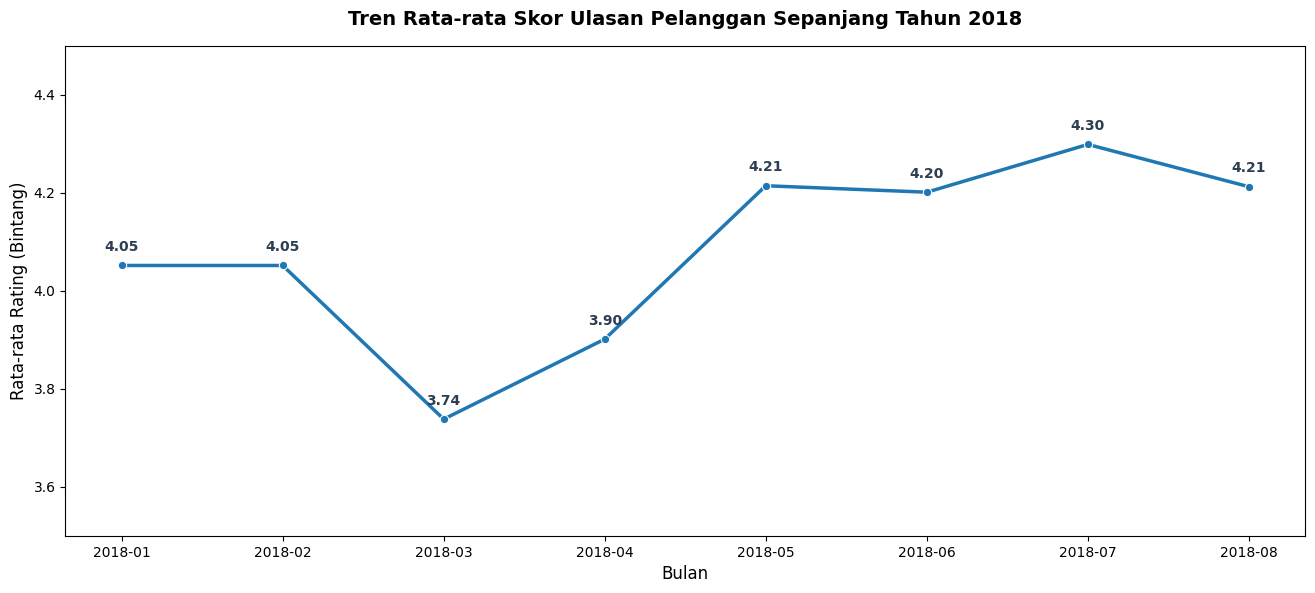

In [59]:
# --- 4. VISUALIZATION & EXPLANATORY ANALYSIS ---

# Menyiapkan canvas untuk dua grafik berdampingan atau berurutan
plt.figure(figsize=(16, 14))

# ------------------------------------------------------------------
# GRAFIK 1: Tren Rata-rata Rating Per Bulan (Pertanyaan Bisnis 1)
# ------------------------------------------------------------------
plt.subplot(2, 1, 1)

# Mengubah tipe data 'month' menjadi string agar sumbu X rapi di grafik
eda_reviews_2018['month_str'] = eda_reviews_2018['month'].astype(str)

# Membuat grafik garis (line plot)
sns.lineplot(
    data=eda_reviews_2018,
    x='month_str',
    y='rata_rata_rating',
    marker='o',
    linewidth=2.5,
    color='#1f77b4'
)

# Menambahkan anotasi angka pada setiap titik koordinat
for x, y in zip(eda_reviews_2018['month_str'], eda_reviews_2018['rata_rata_rating']):
    plt.text(x, y + 0.03, f"{y:.2f}", ha='center', fontweight='bold', color='#2c3e50')

# Kustomisasi teks dan judul Grafik 1
plt.title('Tren Rata-rata Skor Ulasan Pelanggan Sepanjang Tahun 2018', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Bulan', fontsize=12)
plt.ylabel('Rata-rata Rating (Bintang)', fontsize=12)
plt.ylim(3.5, 4.5) # Mengatur batas bawah dan atas agar fluktuasi terlihat jelas

### Pertanyaan 2:

/tmp/ipykernel_1900/4241484703.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


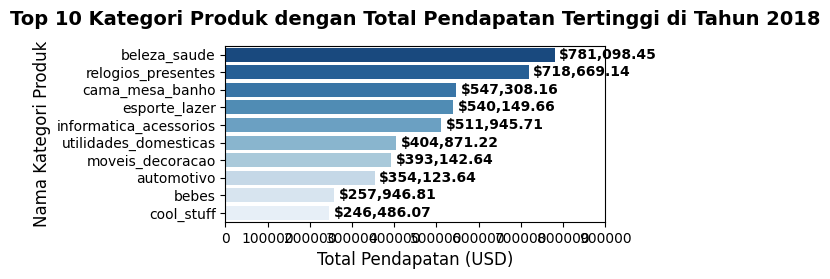

In [60]:
# ------------------------------------------------------------------
# GRAFIK 2: Top 10 Kategori Produk Terlaris (Pertanyaan Bisnis 2)
# ------------------------------------------------------------------
plt.subplot(2, 1, 2)

# Membuat grafik batang horizontal (horizontal bar plot)
sns.barplot(
    data=top_10_categories,
    x='total_pendapatan',
    y='product_category_name',
    palette='Blues_r' # Gradasi warna biru dari gelap ke terang
)

# Menambahkan anotasi nilai total pendapatan di ujung setiap batang
for index, value in enumerate(top_10_categories['total_pendapatan']):
    plt.text(value + 10000, index, f"${value:,.2f}", va='center', fontsize=10, fontweight='bold')

# Kustomisasi teks dan judul Grafik 2
plt.title('Top 10 Kategori Produk dengan Total Pendapatan Tertinggi di Tahun 2018', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Total Pendapatan (USD)', fontsize=12)
plt.ylabel('Nama Kategori Produk', fontsize=12)
plt.xlim(0, 900000) # Memberikan ruang di kanan untuk teks anotasi

# Menampilkan semua grafik
plt.tight_layout()
plt.show()

In [61]:
# Menyimpan data hasil EDA untuk dashboard
df_reviews_2018.to_csv('dashboard_reviews_2018.csv', index=False)
top_10_categories.to_csv('dashboard_top_10_categories.csv', index=False)
print("✓ Data untuk dashboard berhasil disimpan!")

✓ Data untuk dashboard berhasil disimpan!


**Insight:** (Opsional)
- xxx
- xxx

## Analisis Lanjutan (Opsional)

**Insight:** (Opsional)
- xxx
- xxx

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Berdasarkan Grafik 1 (Line Chart), tingkat kepuasan pelanggan sepanjang tahun 2018 berada di level yang baik (di atas 4.0). Namun, grafik menunjukkan penurunan tajam yang membentuk "lembah" pada Maret 2018, di mana rating merosot ke titik terendah yaitu 3.73.

- **Conclusion pertanyaan 2:** Berdasarkan Grafik 2 (Horizontal Bar Chart), kita bisa mengidentifikasi peta kekuatan pendapatan produk Anda secara berurutan.

**Rekomendasi Action Item:**
- Kepuasan pelanggan tidak sepenuhnya stabil. Ada anomali penurunan di bulan Maret. Manajemen disarankan melakukan evaluasi menyeluruh terhadap performa operasional gudang dan kurir pengiriman khusus pada kuartal pertama tersebut untuk mencegah penurunan serupa di musim sibuk berikutnya.
- Kategori beleza_saude (Kesehatan & Kecantikan) adalah penghasil pundi-pundi uang terbesar bagi platform dengan total revenue mencapai $781,098.45, disusul ketat oleh relogios_presentes di posisi kedua sebesar $718,669.14.
Tim Procurement dan Marketing harus menjadikan dua kategori ini sebagai fokus utama program loyalitas pelanggan, promosi besar-besaran, serta memastikan pemenuhan suplai stok agar tidak pernah kehabisan barang (stockout).